<a href="https://colab.research.google.com/github/MElsdk-lab/Biochar_forest_estimation/blob/main/Notebook_2_Forest_Area_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# NOTEBOOK 2 — Forest Area Analysis & FAO Comparison
# University of Pittsburgh | Biochar Feedstock Methodology
# ============================================================

In [2]:
# ── CELL 1: Install Libraries ─────────────────────────────────────────────────
!pip install -q pandas matplotlib

#considering that output of notebook 1 are store
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ── clone repo if not already cloned ─────────────────────
import os
if not os.path.exists('/content/Biochar_forest_estimation'):
    import getpass
    import subprocess
    PAT = getpass.getpass('Enter PAT: ')
    subprocess.run(
        f'git clone https://{PAT}@github.com/MElsdk-lab/Biochar_forest_estimation.git',
        shell=True
    )

%cd /content/Biochar_forest_estimation/

/content/Biochar_forest_estimation


In [4]:
## ── CELL 2: import Libraries and results & data─────────────────────────────────────────────────

import pandas as pd
import matplotlib.pyplot as plt
from data_config import FAO_name_fix, fao_fra_2025, build_country_lookup, FAO_LSIB_REGION, country_thresholds, state_thresholds

print('✅ Libraries imported')
print('✅ Data config loaded')





✅ Libraries imported
✅ Data config loaded


In [5]:
## ── CELL 3  : merge results from notebook1 into main file ─────────────────────────────────────────────────
GEE_FOLDER = ('/content/drive/MyDrive/BiocharProject/GEE_exports/')
country_forest_area_10 = pd.read_csv(GEE_FOLDER + 'forest_area_10.csv')
country_forest_area_20= pd.read_csv(GEE_FOLDER + 'forest_area_20.csv')
country_forest_area_30 = pd.read_csv(GEE_FOLDER + 'forest_area_30.csv')
country_forest_area_40 = pd.read_csv(GEE_FOLDER + 'forest_area_40.csv')
country_forest_area_50  = pd.read_csv(GEE_FOLDER + 'forest_area_50.csv')

country_total_forest_area =pd.concat([country_forest_area_10, country_forest_area_20, country_forest_area_30, country_forest_area_40, country_forest_area_50], ignore_index = True)
country_total_forest_area = country_total_forest_area.groupby(['country_na', 'threshold'])['sum'].sum().reset_index()
country_total_forest_area = country_total_forest_area.rename(columns={'country_na': 'country', 'sum': 'total_forest_area'})

state_forest_area_10 = pd.read_csv(GEE_FOLDER + 'states_forest_area_10.csv')
state_forest_area_20 = pd.read_csv(GEE_FOLDER + 'states_forest_area_20.csv')
state_forest_area_30 = pd.read_csv(GEE_FOLDER + 'states_forest_area_30.csv')
state_forest_area_40 = pd.read_csv(GEE_FOLDER + 'states_forest_area_40.csv')
state_forest_area_50 = pd.read_csv(GEE_FOLDER + 'states_forest_area_50.csv')

state_total_forest_area = pd.concat([state_forest_area_10, state_forest_area_20, state_forest_area_30, state_forest_area_40, state_forest_area_50], ignore_index = True)
state_total_forest_area = state_total_forest_area.groupby(['NAME', 'threshold'])['sum'].sum().reset_index()
state_total_forest_area = state_total_forest_area.rename(columns={'NAME': 'state','sum': 'total_forest_area'})

In [6]:
## ── CELL 4  : build region and subregion info for countries in 'country_total_forest_area' file by the intermidate of FAO_LSIB_REGION   ─────────────────────────────────────────────────
# 1. Generate the lookup dictionary
country_lookup = build_country_lookup(FAO_LSIB_REGION)

# 2. Create the new columns by looking up each country name
# we could actualy transform the country_lookup from a dictionary to a data frame then merge with df bsed onthe country name
country_total_forest_area  ['region'] = country_total_forest_area['country'].map(lambda l: country_lookup.get(l, {}).get('region', 'unknown'))
country_total_forest_area  ['subregion'] = country_total_forest_area['country'].map(lambda l: country_lookup.get(l, {}).get('subregion', 'unknown'))

print(country_total_forest_area.head(3))

       country  threshold  total_forest_area     region  subregion
0  Afghanistan         10           0.427305  Near East  West Asia
1  Afghanistan         20           0.287657  Near East  West Asia
2  Afghanistan         30           0.239637  Near East  West Asia


In [7]:
# ── CELL 5: Clean FAO FRA data ───────────────────────────
fao_fra_2025 = fao_fra_2025.copy()     # work on a copy

# convert all years from 1000 ha to Mha
year_columns = ['1990', '2000', '2010', '2015', '2020', '2025']
fao_fra_2025[year_columns] = fao_fra_2025[year_columns] / 1000


print(fao_fra_2025.head())

       country    1990    2000    2010    2015    2020    2025
0  Afghanistan   1.209   1.209   1.209   1.209   1.209   1.209
1      Albania   0.789   0.769   0.782   0.797   0.941   0.941
2      Algeria   1.715   1.708   1.701   1.698   1.695   1.691
3      Andorra   0.018   0.017   0.018   0.018   0.018   0.018
4       Angola  77.533  76.013  70.913  68.363  65.812  63.262


In [12]:
# ── CELL 6: Merge GEE results with FAO 2000 ──────────────
FAO_forest_area_country_2000 = fao_fra_2025[['country', '2000']].rename(columns={'2000': 'FAO_2000_Mha'})

gee_fao_comparison = country_total_forest_area.merge(FAO_forest_area_country_2000, on='country', how='left')

print(gee_fao_comparison.head(40))
print(f'Total countries: {gee_fao_comparison["country"].nunique()}')

              country  threshold  total_forest_area     region  \
0         Afghanistan         10           0.427305  Near East   
1         Afghanistan         20           0.287657  Near East   
2         Afghanistan         30           0.239637  Near East   
3         Afghanistan         40           0.191961  Near East   
4         Afghanistan         50           0.146759  Near East   
5             Albania         10           0.851593     Europe   
6             Albania         20           0.761100     Europe   
7             Albania         30           0.652909     Europe   
8             Albania         40           0.593420     Europe   
9             Albania         50           0.537382     Europe   
10            Algeria         10           1.714722  Near East   
11            Algeria         20           1.439862  Near East   
12            Algeria         30           1.255206  Near East   
13            Algeria         40           1.130415  Near East   
14        

In [17]:
# ── CELL 7: aggregate by subregion and region. ──────────────

gee_fao_comparison_subregion = gee_fao_comparison.groupby(['subregion', 'threshold']).agg(
    region=('region', 'first'), # Ensure 'region' is carried over
    total_forest_area=('total_forest_area', 'sum'),
    FAO_2000_Mha=('FAO_2000_Mha', 'sum')
).reset_index()

gee_fao_comparison_region = gee_fao_comparison_subregion.groupby(['region', 'threshold']).agg(
    total_forest_area=('total_forest_area', 'sum'),
    FAO_2000_Mha=('FAO_2000_Mha', 'sum')
).reset_index()

gee_fao_comparison_world = gee_fao_comparison_region.groupby(['threshold']).agg(
    total_forest_area=('total_forest_area', 'sum'),
    FAO_2000_Mha=('FAO_2000_Mha', 'sum')
).reset_index()

print(gee_fao_comparison_subregion.head())
print(gee_fao_comparison_region.head())
print(gee_fao_comparison_world.head())

   subregion  threshold    region  total_forest_area  FAO_2000_Mha
0  Caribbean         10  Americas          44.914979        40.852
1  Caribbean         20  Americas          44.302605        40.852
2  Caribbean         30  Americas          43.805069        40.852
3  Caribbean         40  Americas          43.306059        40.852
4  Caribbean         50  Americas          42.577133        40.852
   region  threshold  total_forest_area  FAO_2000_Mha
0  Africa         10        1025.563920       447.528
1  Africa         20         742.245659       447.528
2  Africa         30         574.480914       447.528
3  Africa         40         501.869446       447.528
4  Africa         50         390.544059       447.528
   threshold  total_forest_area  FAO_2000_Mha
0         10        4748.365057      2592.404
1         20        4253.569480      2592.404
2         30        3914.500639      2592.404
3         40        3673.250758      2592.404
4         50        3239.701583      2592.40

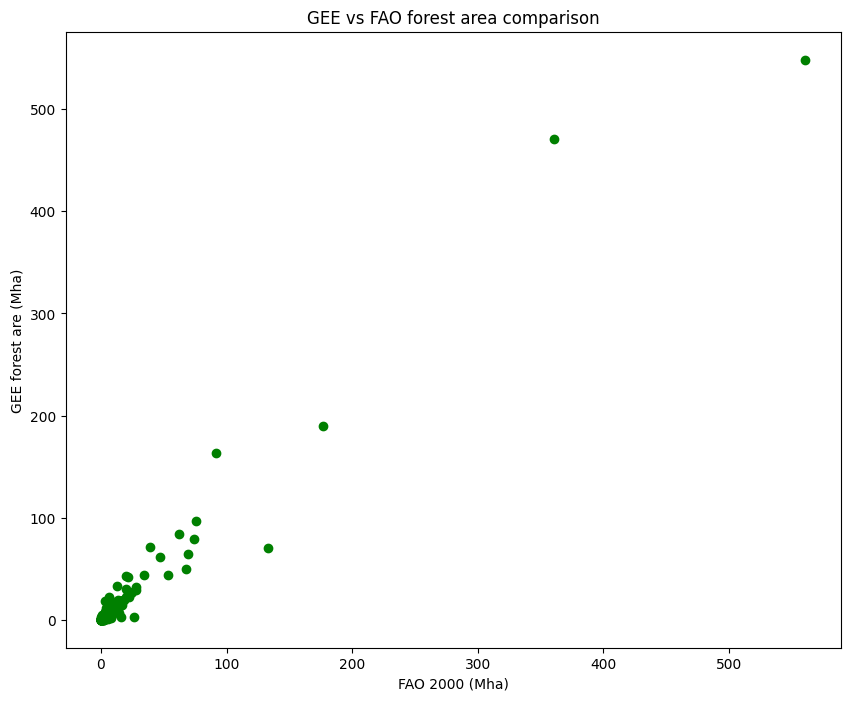

In [23]:
# ── CELL 8: plot GEE vs FAO. ──────────────
df_10 = gee_fao_comparison[gee_fao_comparison['threshold'] == 10]
x_values=df_10['FAO_2000_Mha']
y_values=df_10['total_forest_area']


import matplotlib.pyplot as plt

for threshold_country in country

#create the figure and axes
fig, ax = plt.subplots(figsize=(10, 8))

#plot the dots
ax.scatter(x_values, y_values, color = 'green', label='GEE 10%')

#add labels and title
ax.set_xlabel('FAO 2000 (Mha)')
ax.set_ylabel('GEE forest are (Mha)')
ax.set_title('GEE vs FAO forest area comparison')


#show the plot
plt.show()